In [2]:
cd /Users/hanssenspc/stock_project


/Users/hanssenspc/stock_project


In [3]:
import pandas as pd

df = pd.read_csv("data/monthly_returns.csv", index_col=0, parse_dates=True)

df.head()


,AKRBP.OL,BZ=F,DNB.OL,EQNR.OL,MOWI.OL,NHY.OL,TEL.OL,USDNOK=X,^VIX
Date,,,,,,,,,
2015-02-01,0.213044,0.000000,0.111309,0.125389,-0.046798,-0.039474,-0.075165,-0.005508,-0.363853
2015-03-01,0.138505,0.000000,0.039263,0.000254,-0.043411,-0.032192,0.059168,0.042282,0.146177
2015-04-01,0.235665,0.260238,0.033154,0.113446,-0.005402,-0.160415,0.045427,-0.060499,-0.048398
2015-05-01,-0.070974,-0.018269,0.047161,-0.083019,-0.026073,0.025288,0.034645,0.035672,-0.048797
2015-06-01,0.087169,-0.030049,-0.041758,-0.027463,0.002789,-0.069051,-0.003872,0.010219,0.317196


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 119 entries, 2015-02-01 to 2024-12-01
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AKRBP.OL  119 non-null    float64
 1   BZ=F      119 non-null    float64
 2   DNB.OL    119 non-null    float64
 3   EQNR.OL   119 non-null    float64
 4   MOWI.OL   119 non-null    float64
 5   NHY.OL    119 non-null    float64
 6   TEL.OL    119 non-null    float64
 7   USDNOK=X  119 non-null    float64
 8   ^VIX      119 non-null    float64
dtypes: float64(9)
memory usage: 9.3 KB


In [5]:
df.corr()

,AKRBP.OL,BZ=F,DNB.OL,EQNR.OL,MOWI.OL,NHY.OL,TEL.OL,USDNOK=X,^VIX
AKRBP.OL,1.000000,0.249058,0.452918,0.615293,0.238796,0.334121,-0.037017,-0.384280,-0.343426
BZ=F,0.249058,1.000000,0.131618,0.302565,0.064798,0.086865,-0.076152,-0.300421,-0.078537
DNB.OL,0.452918,0.131618,1.000000,0.391285,0.141824,0.295248,-0.001994,-0.428372,-0.402237
EQNR.OL,0.615293,0.302565,0.391285,1.000000,0.057834,0.390309,-0.070992,-0.266968,-0.322141
MOWI.OL,0.238796,0.064798,0.141824,0.057834,1.000000,0.261676,0.083555,-0.237408,-0.269792
NHY.OL,0.334121,0.086865,0.295248,0.390309,0.261676,1.000000,-0.022183,-0.304258,-0.328291
TEL.OL,-0.037017,-0.076152,-0.001994,-0.070992,0.083555,-0.022183,1.000000,0.089408,-0.114891
USDNOK=X,-0.384280,-0.300421,-0.428372,-0.266968,-0.237408,-0.304258,0.089408,1.000000,0.403560
^VIX,-0.343426,-0.078537,-0.402237,-0.322141,-0.269792,-0.328291,-0.114891,0.403560,1.000000


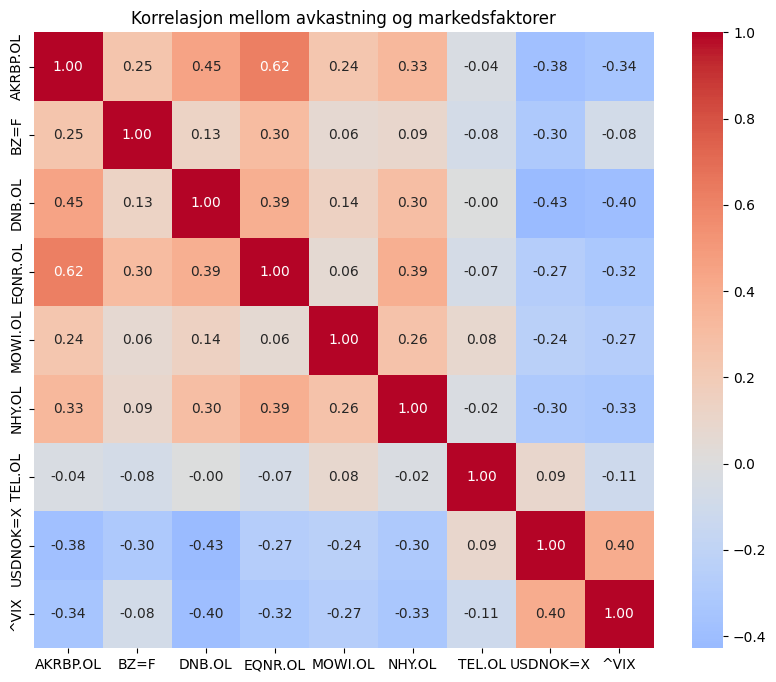

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Korrelasjon mellom avkastning og markedsfaktorer")
plt.show()

In [7]:
import statsmodels.api as sm


y = df["EQNR.OL"]


X = df[["BZ=F", "USDNOK=X", "^VIX"]]


X = sm.add_constant(X)


model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                EQNR.OL   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     8.768
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.76e-05
Time:                        14:57:19   Log-Likelihood:                 162.64
No. Observations:                 119   AIC:                            -317.3
Df Residuals:                     115   BIC:                            -306.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0140      0.006      2.394      0.0

In [8]:
companies = ["AKRBP.OL", "DNB.OL", "EQNR.OL", "MOWI.OL", "NHY.OL", "TEL.OL"]
factors = ["BZ=F", "USDNOK=X", "^VIX"]

results = []

for company in companies:
    y = df[company]
    X = sm.add_constant(df[factors])
    model = sm.OLS(y, X).fit()

    row = {"Selskap": company, "R2": round(model.rsquared, 3)}
    for f in factors:
        coef = model.params[f]
        pval = model.pvalues[f]
        stjerne = "*" if pval < 0.05 else ""   # * = signifikant (p < 0.05)
        row[f] = f"{coef:.3f}{stjerne}"
    results.append(row)

summary = pd.DataFrame(results).set_index("Selskap")
summary


,R2,BZ=F,USDNOK=X,^VIX
Selskap,,,,
AKRBP.OL,0.213,0.170,-0.785*,-0.095*
DNB.OL,0.247,0.010,-0.588*,-0.065*
EQNR.OL,0.186,0.164*,-0.156,-0.065*
MOWI.OL,0.093,0.002,-0.308,-0.053*
NHY.OL,0.143,0.006,-0.551*,-0.084*
TEL.OL,0.037,-0.022,0.217,-0.033


In [9]:
# Nytt datasett bygget spesielt for prediksjon av Equinor
data = pd.DataFrame(index=df.index)

# MÅLVARIABEL: Equinors avkastning DENNE måneden – det vi vil forutsi
data["target"] = df["EQNR.OL"]

# Faktorene vi lager features fra
factors = ["BZ=F", "USDNOK=X", "^VIX"]

for f in factors:
    data[f"{f}_lag1"] = df[f].shift(1)                    # forrige måneds verdi
    data[f"{f}_ma3"]  = df[f].rolling(3).mean().shift(1)  # snitt siste 3 mnd
    data[f"{f}_vol3"] = df[f].rolling(3).std().shift(1)   # volatilitet siste 3 mnd

# Equinors EGEN forrige avkastning (momentum)
data["EQNR_lag1"] = df["EQNR.OL"].shift(1)

# Fjern de første radene som mangler verdier pga. lag/rolling
data = data.dropna()

data.head()

,target,BZ=F_lag1,BZ=F_ma3,BZ=F_vol3,USDNOK=X_lag1,USDNOK=X_ma3,USDNOK=X_vol3,^VIX_lag1,^VIX_ma3,^VIX_vol3,EQNR_lag1
Date,,,,,,,,,,,
2015-05-01,-0.083019,0.260238,0.086746,0.150248,-0.060499,-0.007908,0.051433,-0.048398,-0.088691,0.257391,0.113446
2015-06-01,-0.027463,-0.018269,0.080656,0.155790,0.035672,0.005818,0.057528,-0.048797,0.016327,0.112453,-0.083019
2015-07-01,-0.013562,-0.030049,0.070640,0.164302,0.010219,-0.004869,0.049829,0.317196,0.073334,0.211191,-0.027463
2015-08-01,-0.103473,-0.178959,-0.075759,0.089568,0.036307,0.027399,0.014882,-0.335162,-0.022254,0.326988,-0.013562
2015-09-01,0.014999,0.037158,-0.057283,0.110602,0.014386,0.020304,0.014015,1.345710,0.442581,0.847422,-0.103473


In [10]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.6 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X = data.drop(columns="target")
y = data["target"]

split = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Trening: {len(X_train)} mnd | Test: {len(X_test)} mnd")

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, pred):.4f}")
print(f"R²:   {r2_score(y_test, pred):.4f}")

Trening: 92 mnd | Test: 24 mnd
RMSE: 0.0659
MAE:  0.0527
R²:   0.0689


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, pred_rf):.4f}")
print(f"R²:   {r2_score(y_test, pred_rf):.4f}")

RMSE: 0.0707
MAE:  0.0574
R²:   -0.0729


In [13]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.2 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_xgb)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, pred_xgb):.4f}")
print(f"R²:   {r2_score(y_test, pred_xgb):.4f}")

RMSE: 0.0742
MAE:  0.0584
R²:   -0.1817


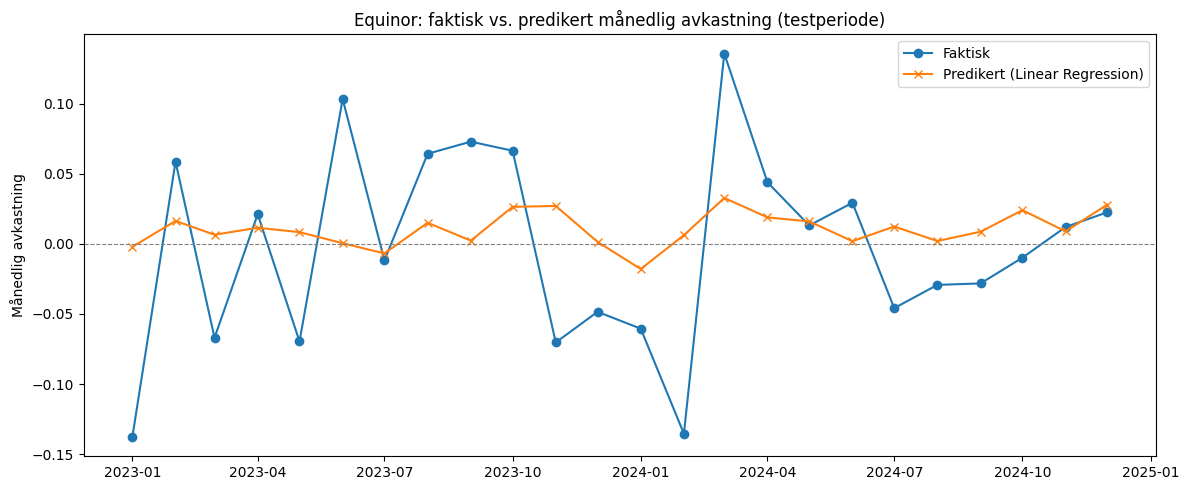

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Faktisk", marker="o")
plt.plot(y_test.index, pred, label="Predikert (Linear Regression)", marker="x")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Equinor: faktisk vs. predikert månedlig avkastning (testperiode)")
plt.ylabel("Månedlig avkastning")
plt.legend()
plt.tight_layout()
plt.show()

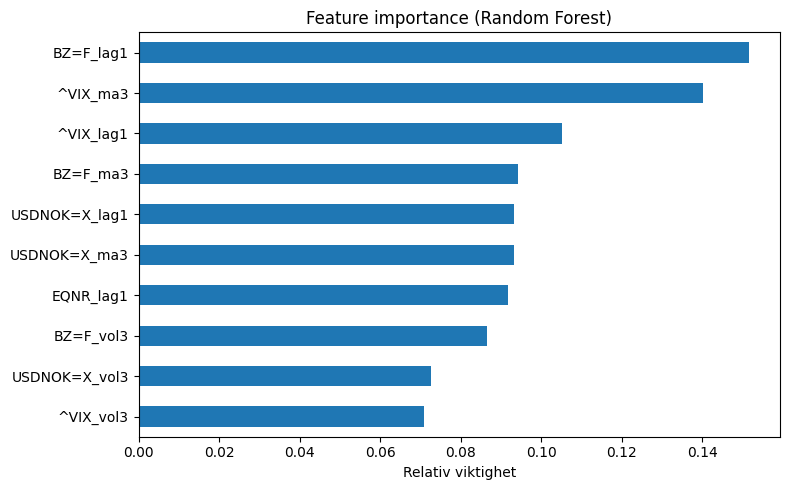

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Feature importance (Random Forest)")
plt.xlabel("Relativ viktighet")
plt.tight_layout()
plt.show()

In [19]:
# 1) Modellsammenligning
model_results = pd.DataFrame({
    "Modell": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred)),
             np.sqrt(mean_squared_error(y_test, pred_rf)),
             np.sqrt(mean_squared_error(y_test, pred_xgb))],
    "MAE":  [mean_absolute_error(y_test, pred),
             mean_absolute_error(y_test, pred_rf),
             mean_absolute_error(y_test, pred_xgb)],
    "R2":   [r2_score(y_test, pred),
             r2_score(y_test, pred_rf),
             r2_score(y_test, pred_xgb)],
}).set_index("Modell").round(4)

# 2) Konklusjoner i tekst
conclusions = pd.DataFrame({"Hovedfunn": [
    "VIX (markedsfrykt) er den mest gjennomgaaende driveren - signifikant negativ for 5 av 6 selskaper.",
    "Oljeprisen er signifikant kun for Equinor; for Aker BP dominerer valutakursen.",
    "Telenor er upaavirket av alle makrofaktorer (R2 = 0,037) - en defensiv aksje.",
    "USD/NOK mister forklaringskraft naar man kontrollerer for VIX (felles risk-off-kanal).",
    "Prediksjon: enkel Linear Regression slaar Random Forest og XGBoost - mer kompleks = mer overfitting.",
    "Modellen fanger svak retning, men ikke de store utslagene - aksjeavkastning er i stor grad uforutsigbar.",
]})

# 3) Skriv alt til Excel med flere ark
with pd.ExcelWriter("stock_returns_report.xlsx", engine="openpyxl") as writer:
    model_results.to_excel(writer, sheet_name="Modellsammenligning")
    summary.to_excel(writer, sheet_name="Regresjon per selskap")
    conclusions.to_excel(writer, sheet_name="Konklusjoner", index=False)

print("Rapport lagret som stock_returns_report.xlsx")

Rapport lagret som stock_returns_report.xlsx
